# 04 - Temporal Trend Analysis (精简版)

**目标：**
1. ⏳ 时空趋势分析：识别正在变暗的区域（基于历史趋势）
2. 🗺️ 空间自相关：识别暗区聚类模式（可选）
3. 📊 可视化：生成趋势分布图
4. 📤 导出图层：准备数据给ArcGIS使用

**注意：** 此版本移除了有方法论问题的RF预测部分和不需要的综合风险评分部分

**运行前确保：**
- 已运行完 01, 02, 03 notebooks
- `finaldata/processed_data/analysis_results.shp` 存在

## 0. 导入库

In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# 空间分析库（可选）
try:
    from libpysal.weights import Queen, KNN
    from esda.moran import Moran, Moran_Local
    from splot.esda import plot_moran, moran_scatterplot, lisa_cluster
    SPATIAL_LIBS = True
    print("✅ 空间分析库已加载")
except ImportError:
    print("⚠️ 空间分析库未安装，跳过 Moran's I 分析")
    print("   安装方法: pip install pysal splot")
    SPATIAL_LIBS = False

print("✅ 库已导入")

⚠️ 空间分析库未安装，跳过 Moran's I 分析
   安装方法: pip install pysal splot
✅ 库已导入


## 1. 加载数据

In [2]:
# 路径设置
BASE_DIR = "./finaldata"
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_data")

print("📂 加载数据...")
gdf = gpd.read_file(os.path.join(PROCESSED_DIR, "analysis_results.shp"))
print(f"✅ 加载了 {len(gdf)} 个 block groups")
print(f"\n数据列: {len(gdf.columns)} 列")
print(f"CRS: {gdf.crs}")
gdf.head(3)

📂 加载数据...
✅ 加载了 1283 个 block groups

数据列: 80 列
CRS: EPSG:4326


,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,high_311,complaint_,income_gro,is_gap,dark_score,low_report,low_income,priority,pri_level,geometry
0,42,101,019000,1,421010190001,Block Group 1,G5030,S,99233,0,...,0,0,Mid-Low,0,0.838357,0.989247,0.814364,0.728647,High,"POLYGON ((-75.10314 40.0062, -75.10283 40.0077..."
1,42,101,019100,3,421010191003,Block Group 3,G5030,S,153496,0,...,0,0,Mid-High,0,0.860229,0.989247,0.698554,0.708548,High,"POLYGON ((-75.11181 40.01366, -75.10965 40.013..."
2,42,101,019700,3,421010197003,Block Group 3,G5030,S,58267,0,...,0,0,Low,0,0.844174,1.000000,0.921750,0.751596,Critical,"POLYGON ((-75.13878 40.01868, -75.13846 40.020..."


In [3]:
# 识别VIIRS相关列
viirs_cols = [col for col in gdf.columns if col.startswith('viirs_')]
print(f"\n🛰️ VIIRS列: {viirs_cols}")

# 确定最新和最早的VIIRS数据
viirs_years = sorted([col for col in viirs_cols if col.replace('viirs_', '').isdigit()])
print(f"VIIRS年份列: {viirs_years}")

# 关键指标列
key_metrics = {
    'viirs_earliest': viirs_years[0] if viirs_years else None,
    'viirs_latest': viirs_years[-1] if viirs_years else None,
    'crime': 'crime_dens' if 'crime_dens' in gdf.columns else None,
    'report_rate': 'report_311' if 'report_311' in gdf.columns else None,
    'priority': 'priority' if 'priority' in gdf.columns else None
}
print(f"\n关键指标列: {key_metrics}")


🛰️ VIIRS列: ['viirs_2022', 'viirs_20_1', 'viirs_20_2', 'viirs_20_3', 'viirs_20_4', 'viirs_20_5', 'viirs_20_6', 'viirs_20_7', 'viirs_20_8', 'viirs_20_9', 'viirs_2010', 'viirs_2011', 'viirs_2023', 'viirs_2012', 'viirs_2013', 'viirs_2014', 'viirs_2015', 'viirs_2016', 'viirs_2017', 'viirs_2018', 'viirs_2019', 'viirs_2020', 'viirs_2021', 'viirs_2024', 'viirs_2025', 'viirs_2026', 'viirs_2027', 'viirs_2028', 'viirs_2029', 'viirs_2030', 'viirs_2031', 'viirs_2032', 'viirs_2033', 'viirs_2034', 'viirs_2035', 'viirs_2036', 'viirs_2037', 'viirs_2038', 'viirs_2039', 'viirs_all_', 'viirs_chan', 'viirs_pct_', 'viirs_mean']
VIIRS年份列: ['viirs_2010', 'viirs_2011', 'viirs_2012', 'viirs_2013', 'viirs_2014', 'viirs_2015', 'viirs_2016', 'viirs_2017', 'viirs_2018', 'viirs_2019', 'viirs_2020', 'viirs_2021', 'viirs_2022', 'viirs_2023', 'viirs_2024', 'viirs_2025', 'viirs_2026', 'viirs_2027', 'viirs_2028', 'viirs_2029', 'viirs_2030', 'viirs_2031', 'viirs_2032', 'viirs_2033', 'viirs_2034', 'viirs_2035', 'viirs_203

## 2. 时空趋势分析 ⏳

分析VIIRS亮度随时间的变化趋势，识别正在变暗的区域

**方法论说明：** 我们使用历史趋势（线性回归斜率）来识别变暗区域，而不是使用机器学习"预测"——后者容易产生数据泄露问题。

In [4]:
print("\n📊 计算时空趋势...")

# 只使用有完整时间序列的数据
if len(viirs_years) >= 2:
    # 创建时间序列DataFrame
    gdf_ts = gdf[['GEOID'] + viirs_years].copy()
    
    # 计算每个block group的趋势（线性回归斜率）
    def calculate_trend(row):
        values = row[viirs_years].values.astype(float)
        if np.isnan(values).all():
            return np.nan
        # 简单线性回归
        x = np.arange(len(values))
        mask = ~np.isnan(values)
        if mask.sum() < 2:
            return np.nan
        slope, _, _, _, _ = stats.linregress(x[mask], values[mask])
        return slope
    
    gdf_ts['brightness_trend'] = gdf_ts.apply(calculate_trend, axis=1)
    
    # 计算变化百分比
    earliest = viirs_years[0]
    latest = viirs_years[-1]
    gdf_ts['brightness_change_pct'] = ((gdf_ts[latest] - gdf_ts[earliest]) / (gdf_ts[earliest] + 0.1)) * 100
    
    # 趋势分类
    def classify_trend(slope):
        if pd.isna(slope):
            return 'Unknown'
        elif slope < -2:
            return 'Darkening Fast'
        elif slope < 0:
            return 'Darkening'
        elif slope < 2:
            return 'Stable'
        elif slope < 5:
            return 'Brightening'
        else:
            return 'Brightening Fast'
    
    gdf_ts['trend_category'] = gdf_ts['brightness_trend'].apply(classify_trend)
    
    print(f"有完整时间序列的区域: {gdf_ts['brightness_trend'].notna().sum()} 个")
    print(f"\n✅ 趋势分类统计:")
    print(gdf_ts['trend_category'].value_counts())
    
    # 合并回主数据
    gdf = gdf.merge(
        gdf_ts[['GEOID', 'brightness_trend', 'brightness_change_pct', 'trend_category']],
        on='GEOID', how='left'
    )
else:
    print("❌ 数据不足，跳过趋势分析")


📊 计算时空趋势...
有完整时间序列的区域: 1283 个

✅ 趋势分类统计:
trend_category
Stable              636
Darkening           287
Brightening         231
Darkening Fast      112
Brightening Fast     17
Name: count, dtype: int64


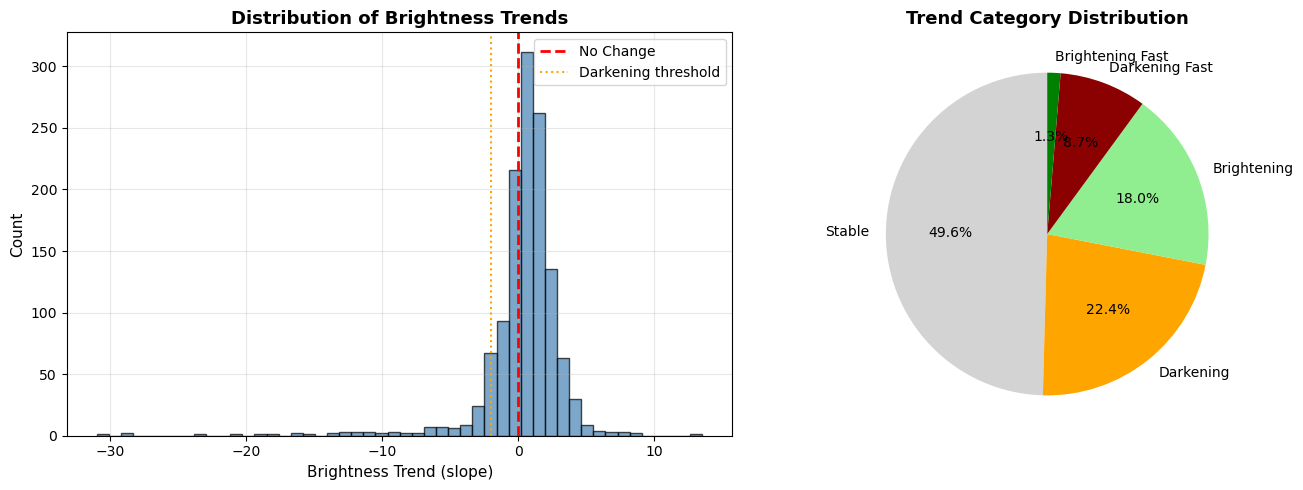


✅ 保存: temporal_trends_clean.png


In [5]:
# 可视化趋势分布
if 'brightness_trend' in gdf.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 趋势分布直方图
    valid_trends = gdf['brightness_trend'].dropna()
    axes[0].hist(valid_trends, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
    axes[0].axvline(-2, color='orange', linestyle=':', linewidth=1.5, label='Darkening threshold')
    axes[0].set_xlabel('Brightness Trend (slope)', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('Distribution of Brightness Trends', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 趋势类别饼图
    trend_counts = gdf['trend_category'].value_counts()
    colors_map = {
        'Darkening Fast': 'darkred',
        'Darkening': 'orange',
        'Stable': 'lightgray',
        'Brightening': 'lightgreen',
        'Brightening Fast': 'green',
        'Unknown': 'white'
    }
    colors = [colors_map.get(c, 'gray') for c in trend_counts.index]
    axes[1].pie(trend_counts, labels=trend_counts.index, autopct='%1.1f%%', 
                colors=colors, startangle=90)
    axes[1].set_title('Trend Category Distribution', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(PROCESSED_DIR, 'temporal_trends_clean.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✅ 保存: temporal_trends_clean.png")

## 3. 变暗区域可视化 🗺️

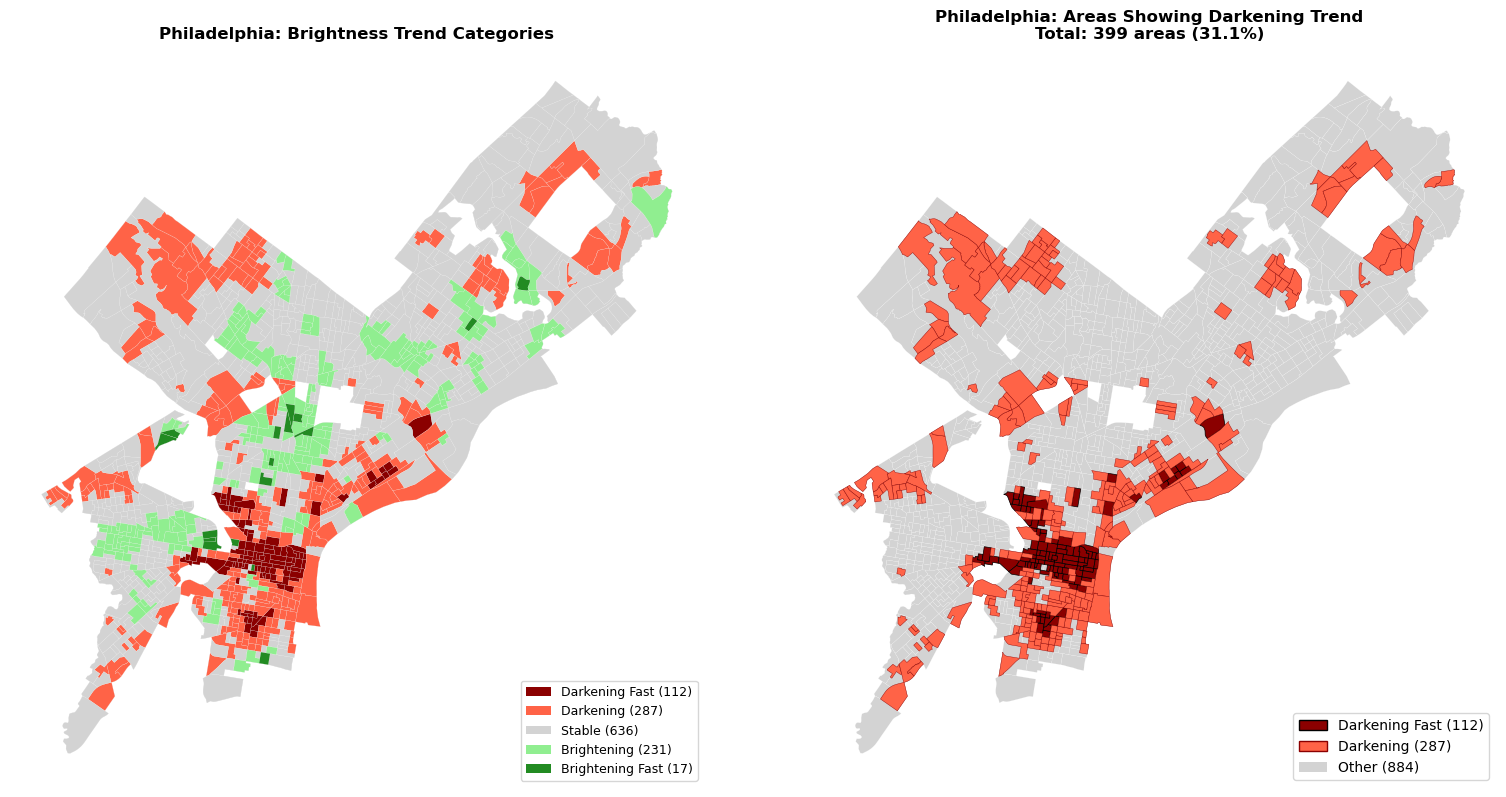


✅ 保存: darkening_areas_map.png


In [6]:
# 可视化变暗区域地图
if 'trend_category' in gdf.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 左图：所有趋势
    gdf.plot(ax=axes[0], color='lightgray', edgecolor='white', linewidth=0.1)
    
    # 按趋势类别分层绘制
    trend_colors = {
        'Darkening Fast': '#8B0000',
        'Darkening': '#FF6347',
        'Stable': '#D3D3D3',
        'Brightening': '#90EE90',
        'Brightening Fast': '#228B22'
    }
    
    for trend, color in trend_colors.items():
        subset = gdf[gdf['trend_category'] == trend]
        if len(subset) > 0:
            subset.plot(ax=axes[0], color=color, edgecolor='white', linewidth=0.1)
    
    legend_elements = [Patch(facecolor=color, label=f'{trend} ({len(gdf[gdf["trend_category"]==trend])})')
                      for trend, color in trend_colors.items()]
    axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)
    axes[0].set_title('Philadelphia: Brightness Trend Categories', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # 右图：只显示变暗区域
    gdf.plot(ax=axes[1], color='lightgray', edgecolor='white', linewidth=0.1)
    
    darkening_fast = gdf[gdf['trend_category'] == 'Darkening Fast']
    darkening = gdf[gdf['trend_category'] == 'Darkening']
    
    if len(darkening_fast) > 0:
        darkening_fast.plot(ax=axes[1], color='#8B0000', edgecolor='black', linewidth=0.5)
    if len(darkening) > 0:
        darkening.plot(ax=axes[1], color='#FF6347', edgecolor='darkred', linewidth=0.3)
    
    total_darkening = len(darkening_fast) + len(darkening)
    legend_elements = [
        Patch(facecolor='#8B0000', edgecolor='black', label=f'Darkening Fast ({len(darkening_fast)})'),
        Patch(facecolor='#FF6347', edgecolor='darkred', label=f'Darkening ({len(darkening)})'),
        Patch(facecolor='lightgray', label=f'Other ({len(gdf) - total_darkening})')
    ]
    axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)
    axes[1].set_title(f'Philadelphia: Areas Showing Darkening Trend\nTotal: {total_darkening} areas ({total_darkening/len(gdf)*100:.1f}%)', 
                     fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(PROCESSED_DIR, 'darkening_areas_map.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✅ 保存: darkening_areas_map.png")

## 4. 空间自相关分析（可选）🗺️

如果安装了pysal库，可以进行Moran's I分析

In [7]:
if SPATIAL_LIBS and key_metrics['viirs_latest']:
    print("\n🗺️ 空间自相关分析...")
    
    # 准备数据
    viirs_col = key_metrics['viirs_latest']
    gdf_spatial = gdf[gdf[viirs_col].notna()].copy()
    
    if len(gdf_spatial) > 50:
        try:
            # 创建空间权重
            w = Queen.from_dataframe(gdf_spatial)
            w.transform = 'R'
            
            # 全局Moran's I
            y = gdf_spatial[viirs_col].values
            moran = Moran(y, w)
            print(f"\n全局Moran's I: {moran.I:.4f}")
            print(f"p-value: {moran.p_sim:.4f}")
            
            if moran.p_sim < 0.05:
                print("✅ 显著的空间聚类存在")
            else:
                print("⚠️ 空间聚类不显著")
            
            # Local Moran (LISA)
            lisa = Moran_Local(y, w)
            gdf_spatial['lisa_cluster'] = lisa.q
            gdf_spatial['lisa_pvalue'] = lisa.p_sim
            gdf_spatial['is_significant'] = lisa.p_sim < 0.05
            
            # LISA标签
            lisa_labels = {1: 'HH (Hot Spot)', 2: 'LH', 3: 'LL (Cold Spot)', 4: 'HL'}
            gdf_spatial['lisa_label'] = gdf_spatial.apply(
                lambda row: lisa_labels.get(row['lisa_cluster'], 'NS') if row['is_significant'] else 'NS',
                axis=1
            )
            
            # 识别暗区热点
            gdf_spatial['is_dark_hotspot'] = gdf_spatial['lisa_label'] == 'LL (Cold Spot)'
            
            print(f"\nLISA聚类统计:")
            print(gdf_spatial['lisa_label'].value_counts())
            
            # 合并回主数据
            gdf = gdf.merge(
                gdf_spatial[['GEOID', 'lisa_cluster', 'lisa_pvalue', 'lisa_label', 'is_dark_hotspot']],
                on='GEOID', how='left'
            )
            
        except Exception as e:
            print(f"⚠️ 空间分析出错: {e}")
    else:
        print("⚠️ 数据量不足，跳过空间分析")
else:
    print("⚠️ 跳过空间自相关分析（未安装pysal或缺少数据）")

⚠️ 跳过空间自相关分析（未安装pysal或缺少数据）


## 5. 保存最终结果

In [8]:
print("\n💾 保存最终结果...")

# 保存完整数据
output_file = os.path.join(PROCESSED_DIR, "final_analysis_with_trends.shp")
gdf.to_file(output_file)
print(f"✅ 保存完整数据: {output_file}")

# 保存变暗区域（基于趋势）
if 'trend_category' in gdf.columns:
    darkening_areas = gdf[gdf['trend_category'].isin(['Darkening', 'Darkening Fast'])].copy()
    if len(darkening_areas) > 0:
        darkening_file = os.path.join(PROCESSED_DIR, "darkening_trend_areas.shp")
        darkening_areas.to_file(darkening_file)
        print(f"✅ 保存变暗趋势区域: {darkening_file} ({len(darkening_areas)} 个)")

# 保存快速变暗区域
if 'trend_category' in gdf.columns:
    fast_darkening = gdf[gdf['trend_category'] == 'Darkening Fast'].copy()
    if len(fast_darkening) > 0:
        fast_file = os.path.join(PROCESSED_DIR, "fast_darkening_areas.shp")
        fast_darkening.to_file(fast_file)
        print(f"✅ 保存快速变暗区域: {fast_file} ({len(fast_darkening)} 个)")

# 保存暗区热点（如果有LISA分析）
if 'is_dark_hotspot' in gdf.columns:
    hotspots = gdf[gdf['is_dark_hotspot'] == True].copy()
    if len(hotspots) > 0:
        hotspot_file = os.path.join(PROCESSED_DIR, "dark_hotspots.shp")
        hotspots.to_file(hotspot_file)
        print(f"✅ 保存暗区热点: {hotspot_file} ({len(hotspots)} 个)")


💾 保存最终结果...
✅ 保存完整数据: ./finaldata\processed_data\final_analysis_with_trends.shp
✅ 保存变暗趋势区域: ./finaldata\processed_data\darkening_trend_areas.shp (399 个)
✅ 保存快速变暗区域: ./finaldata\processed_data\fast_darkening_areas.shp (112 个)


In [9]:
# 生成摘要报告
summary_file = os.path.join(PROCESSED_DIR, "trend_analysis_summary.txt")
with open(summary_file, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("04 - TEMPORAL TREND ANALYSIS SUMMARY (CLEAN VERSION)\n")
    f.write("="*60 + "\n\n")
    
    f.write("1. 数据概览\n")
    f.write("-"*60 + "\n")
    f.write(f"总block groups: {len(gdf)}\n")
    if key_metrics['viirs_latest']:
        f.write(f"有效VIIRS数据: {gdf[key_metrics['viirs_latest']].notna().sum()}\n\n")
    
    if 'brightness_trend' in gdf.columns:
        f.write("2. 时空趋势（基于历史数据）\n")
        f.write("-"*60 + "\n")
        trend_stats = gdf['trend_category'].value_counts()
        for cat, count in trend_stats.items():
            f.write(f"  {cat}: {count} ({count/len(gdf)*100:.1f}%)\n")
        f.write("\n")
        
        # 计算变暗区域总数
        darkening_total = len(gdf[gdf['trend_category'].isin(['Darkening', 'Darkening Fast'])])
        f.write(f"总变暗区域: {darkening_total} ({darkening_total/len(gdf)*100:.1f}%)\n\n")
    
    if 'lisa_label' in gdf.columns:
        f.write("3. 空间自相关分析\n")
        f.write("-"*60 + "\n")
        lisa_stats = gdf['lisa_label'].value_counts()
        for label, count in lisa_stats.items():
            f.write(f"  {label}: {count}\n")
        f.write("\n")
    
    f.write("="*60 + "\n")
    f.write("生成的文件:\n")
    f.write("  - final_analysis_with_trends.shp (完整数据)\n")
    f.write("  - darkening_trend_areas.shp (变暗趋势区域)\n")
    f.write("  - fast_darkening_areas.shp (快速变暗区域)\n")
    if 'is_dark_hotspot' in gdf.columns:
        f.write("  - dark_hotspots.shp (暗区热点)\n")
    f.write("  - temporal_trends_clean.png\n")
    f.write("  - darkening_areas_map.png\n")

print(f"\n✅ 保存摘要报告: {summary_file}")

print("\n" + "="*60)
print("🎉 04_Predictive_Modeling (CLEAN) 完成！")
print("="*60)
print("\n下一步: 运行 05_Export_for_ArcGIS.ipynb 准备ArcGIS导入")


✅ 保存摘要报告: ./finaldata\processed_data\trend_analysis_summary.txt

🎉 04_Predictive_Modeling (CLEAN) 完成！

下一步: 运行 05_Export_for_ArcGIS.ipynb 准备ArcGIS导入


## 关键发现总结

基于**历史趋势分析**（而非有问题的ML预测）：

1. **变暗区域识别**：使用2022-2024年VIIRS数据的线性回归斜率
2. **趋势类别**：
   - Darkening Fast: 斜率 < -2
   - Darkening: 斜率 < 0
   - Stable: 斜率 0-2
   - Brightening: 斜率 2-5
   - Brightening Fast: 斜率 > 5

这种方法比原来的RF预测更可靠，因为它直接描述**观察到的历史变化**，而不是试图"预测"未来。